# SAIR — Module 5, Appendix 0: PyTorch Crash Course

## Introduction

This notebook is a **focused crash course** — not a full PyTorch tutorial. It covers exactly the concepts you will encounter when building GPT from scratch in Notebooks 1–5, nothing more.

If you have worked with PyTorch before, skim it as a refresher. If you are new, work through every cell before moving on.

### What This Covers

| Topic | Why You Need It |
|-------|----------------|
| Tensors | Everything in GPT is a tensor |
| Autograd | How the model learns from its mistakes |
| `nn.Module` | How we build GPT layers |
| Key layers | `Linear`, `Embedding`, `LayerNorm`, `Dropout` |
| Training loop | `zero_grad → forward → loss → backward → step` |
| GPU | Moving tensors and models to the GPU |
| `Dataset` + `DataLoader` | How we feed text to the model in batches |

> Estimated time: 45–60 minutes

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available  : {torch.cuda.is_available()}")

PyTorch version: 2.10.0+cu128
GPU available  : True


---
## 1 — Tensors

A **tensor** is an n-dimensional array — the fundamental data structure in PyTorch. Scalars, vectors, matrices, and batches of sequences are all tensors.

In GPT, the input to the model is a tensor of shape `(batch_size, sequence_length)` holding token IDs.

In [2]:
# Creating tensors
scalar = torch.tensor(42)
vector = torch.tensor([1, 2, 3])
matrix = torch.tensor([[1, 2], [3, 4], [5, 6]])

print(f"scalar : {scalar}  shape={scalar.shape}")
print(f"vector : {vector}  shape={vector.shape}")
print(f"matrix : \n{matrix}  shape={matrix.shape}")

scalar : 42  shape=torch.Size([])
vector : tensor([1, 2, 3])  shape=torch.Size([3])
matrix : 
tensor([[1, 2],
        [3, 4],
        [5, 6]])  shape=torch.Size([3, 2])


In [3]:
# dtypes you will see in GPT
token_ids  = torch.tensor([15496, 995], dtype=torch.long)    # token IDs are integers (long)
embeddings = torch.tensor([0.1, 0.5, 0.9], dtype=torch.float32)  # weights are floats

print(f"token_ids  dtype: {token_ids.dtype}")
print(f"embeddings dtype: {embeddings.dtype}")

# Utility constructors
zeros   = torch.zeros(2, 3)       # 2x3 matrix of zeros
ones    = torch.ones(2, 3)        # 2x3 matrix of ones
randn   = torch.randn(2, 3)       # 2x3 from standard normal distribution
arange  = torch.arange(0, 10, 2)  # [0, 2, 4, 6, 8]

print(f"\nzeros:\n{zeros}")
print(f"\nrandn:\n{randn}")
print(f"\narange: {arange}")

token_ids  dtype: torch.int64
embeddings dtype: torch.float32

zeros:
tensor([[0., 0., 0.],
        [0., 0., 0.]])

randn:
tensor([[-0.5256, -1.9632, -1.0815],
        [-0.7837, -1.2762, -1.2045]])

arange: tensor([0, 2, 4, 6, 8])


In [4]:
# Shape manipulation — used constantly in attention
x = torch.randn(2, 4)          # (batch=2, features=4)
print(f"Original shape : {x.shape}")

# reshape / view
print(f"view(8)        : {x.view(8).shape}")      # flatten
print(f"view(4, 2)     : {x.view(4, 2).shape}")   # reshape

# unsqueeze / squeeze — add or remove a dimension
x_unsq = x.unsqueeze(0)         # (1, 2, 4) — add batch dimension
x_sq   = x_unsq.squeeze(0)      # (2, 4)   — remove it
print(f"unsqueeze(0)   : {x_unsq.shape}")
print(f"squeeze(0)     : {x_sq.shape}")

# transpose / permute — reorder dimensions
print(f"transpose(0,1) : {x.transpose(0, 1).shape}")  # (4, 2)

Original shape : torch.Size([2, 4])
view(8)        : torch.Size([8])
view(4, 2)     : torch.Size([4, 2])
unsqueeze(0)   : torch.Size([1, 2, 4])
squeeze(0)     : torch.Size([2, 4])
transpose(0,1) : torch.Size([4, 2])


In [5]:
# Indexing and slicing — same as NumPy
x = torch.arange(12).view(3, 4)
print(f"Full tensor:\n{x}")
print(f"Row 0        : {x[0]}")
print(f"Col 1        : {x[:, 1]}")
print(f"Rows 0-1     : {x[:2]}")
print(f"x[1, 2]      : {x[1, 2]}")

Full tensor:
tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
Row 0        : tensor([0, 1, 2, 3])
Col 1        : tensor([1, 5, 9])
Rows 0-1     : tensor([[0, 1, 2, 3],
        [4, 5, 6, 7]])
x[1, 2]      : 6


In [6]:
# Operations used in GPT
a = torch.randn(3, 4)
b = torch.randn(4, 2)

# Matrix multiplication — the heart of every linear layer and attention score
c = a @ b                        # equivalent to torch.matmul(a, b)
print(f"a @ b shape: {c.shape}")  # (3, 2)

# Element-wise operations
x = torch.tensor([1.0, 2.0, 3.0])
print(f"x * 2      : {x * 2}")
print(f"x + x      : {x + x}")
print(f"softmax(x) : {F.softmax(x, dim=-1)}")

# cat — used when building sequences token by token during inference
a = torch.tensor([[1, 2, 3]])
b = torch.tensor([[4]])
print(f"cat along dim=1: {torch.cat([a, b], dim=1)}")

a @ b shape: torch.Size([3, 2])
x * 2      : tensor([2., 4., 6.])
x + x      : tensor([2., 4., 6.])
softmax(x) : tensor([0.0900, 0.2447, 0.6652])
cat along dim=1: tensor([[1, 2, 3, 4]])


---
## 2 — Autograd: How the Model Learns

PyTorch tracks every operation on tensors with `requires_grad=True`. When you call `loss.backward()`, it automatically computes the gradient of the loss with respect to every parameter — this is called **automatic differentiation**.

You never write gradient formulas by hand. PyTorch does it for you.

In [7]:
# A simple example: y = x^2, dy/dx = 2x
x = torch.tensor(3.0, requires_grad=True)  # track gradients
y = x ** 2
y.backward()                               # compute dy/dx
print(f"x     = {x.item()}")
print(f"y     = {y.item()}  (x^2)")
print(f"dy/dx = {x.grad.item()}  (should be 2*3 = 6)")

x     = 3.0
y     = 9.0  (x^2)
dy/dx = 6.0  (should be 2*3 = 6)


In [8]:
# torch.no_grad() — disable gradient tracking during inference
# This saves memory and speeds up forward passes when you don't need gradients

x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)

with torch.no_grad():          # no gradient tape inside this block
    y = x * 2
    print(f"y.requires_grad inside no_grad: {y.requires_grad}")  # False

# Always use torch.no_grad() during evaluation and inference

y.requires_grad inside no_grad: False


In [9]:
# .detach() — cut a tensor out of the computation graph
# Used when accumulating losses without wanting gradients to flow back

x = torch.tensor(2.0, requires_grad=True)
y = x * 3
z = y.detach()                  # z is a plain tensor, not connected to x

print(f"y.requires_grad : {y.requires_grad}")  # True
print(f"z.requires_grad : {z.requires_grad}")  # False

y.requires_grad : True
z.requires_grad : False


---
## 3 — nn.Module: Building Layers

Every component of GPT — attention, feedforward, layer norm, the full model — is a subclass of `nn.Module`. The pattern is always the same:

1. Define layers in `__init__`
2. Define the forward pass in `forward`

In [10]:
# The simplest possible nn.Module
class SimpleLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()                              # always call this first
        self.linear = nn.Linear(in_features, out_features)

    def forward(self, x):
        return self.linear(x)


layer = SimpleLayer(4, 2)
x_in  = torch.randn(3, 4)      # batch of 3 vectors, each length 4
x_out = layer(x_in)            # calls forward() automatically
print(f"Input  shape: {x_in.shape}")
print(f"Output shape: {x_out.shape}")

# Inspect parameters
for name, param in layer.named_parameters():
    print(f"  {name}: shape={param.shape}, requires_grad={param.requires_grad}")

Input  shape: torch.Size([3, 4])
Output shape: torch.Size([3, 2])
  linear.weight: shape=torch.Size([2, 4]), requires_grad=True
  linear.bias: shape=torch.Size([2]), requires_grad=True


In [11]:
# Composing modules — nn.Sequential stacks layers in order
# This is how GPT's FeedForward block is built

ffn = nn.Sequential(
    nn.Linear(8, 32),    # expand
    nn.GELU(),           # activation
    nn.Linear(32, 8),    # project back
)

x = torch.randn(2, 8)
out = ffn(x)
print(f"FFN input  shape: {x.shape}")
print(f"FFN output shape: {out.shape}")

# Count parameters
total = sum(p.numel() for p in ffn.parameters())
print(f"FFN parameters : {total:,}")

FFN input  shape: torch.Size([2, 8])
FFN output shape: torch.Size([2, 8])
FFN parameters : 552


---
## 4 — Key Layers Used in GPT

Four layers appear repeatedly across GPT Notebooks 2, 3, and 4.

In [12]:
# --- nn.Embedding ---
# Maps integer token IDs to dense vectors
# GPT has two: one for tokens, one for positions

vocab_size = 100
emb_dim    = 8
emb        = nn.Embedding(vocab_size, emb_dim)

token_ids = torch.tensor([4, 15, 2, 7])   # a sequence of 4 token IDs
vectors   = emb(token_ids)                # look up embedding for each token
print(f"Token IDs shape  : {token_ids.shape}")
print(f"Embedding output : {vectors.shape}   (4 tokens x 8 dims)")

Token IDs shape  : torch.Size([4])
Embedding output : torch.Size([4, 8])   (4 tokens x 8 dims)


In [13]:
# --- nn.Linear ---
# y = xW^T + b  — the most used layer in deep learning
# Used in Q, K, V projections, feedforward layers, and the output head

linear = nn.Linear(in_features=8, out_features=4)
x      = torch.randn(3, 8)     # batch of 3, each 8-dimensional
out    = linear(x)
print(f"Linear: {x.shape} -> {out.shape}")
print(f"Weight shape: {linear.weight.shape}, Bias shape: {linear.bias.shape}")

Linear: torch.Size([3, 8]) -> torch.Size([3, 4])
Weight shape: torch.Size([4, 8]), Bias shape: torch.Size([4])


In [14]:
# --- nn.LayerNorm ---
# Normalizes across the feature dimension — stabilizes training
# GPT applies LayerNorm before each attention and feedforward block

layer_norm = nn.LayerNorm(normalized_shape=8)
x   = torch.randn(3, 8)         # batch=3, features=8
out = layer_norm(x)
print(f"LayerNorm: {x.shape} -> {out.shape}")
print(f"Mean before norm : {x.mean(dim=-1).tolist()}")
print(f"Mean after  norm : {[round(v,4) for v in out.mean(dim=-1).tolist()]}  (≈ 0)")

LayerNorm: torch.Size([3, 8]) -> torch.Size([3, 8])
Mean before norm : [0.4308306574821472, 0.3302174210548401, -0.044230807572603226]
Mean after  norm : [0.0, 0.0, 0.0]  (≈ 0)


In [15]:
# --- nn.Dropout ---
# Randomly zeroes out activations during training — prevents overfitting
# Only active when model.train() is set; disabled in model.eval()

dropout = nn.Dropout(p=0.5)    # 50% of values become 0
x = torch.ones(2, 8)

dropout.train()                # training mode — dropout is active
out_train = dropout(x)
print(f"Training mode output:\n{out_train}")

dropout.eval()                 # eval mode — dropout is disabled
out_eval = dropout(x)
print(f"\nEval mode output:\n{out_eval}")

Training mode output:
tensor([[0., 2., 2., 0., 2., 2., 2., 2.],
        [2., 2., 2., 2., 0., 0., 2., 2.]])

Eval mode output:
tensor([[1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.]])


---
## 5 — The Training Loop

Every training step in Notebook 4 follows this exact pattern. Memorize it.

```
optimizer.zero_grad()   # 1. clear gradients from last step
output = model(input)   # 2. forward pass
loss = criterion(...)   # 3. compute loss
loss.backward()         # 4. compute gradients
optimizer.step()        # 5. update weights
```

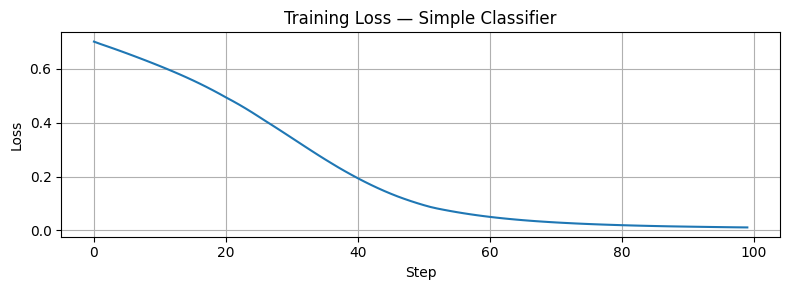

Final loss: 0.0112


In [16]:
# A complete minimal training loop
# Task: learn to map [1,0] -> 0, [0,1] -> 1  (binary classification)

torch.manual_seed(42)

# Data
X = torch.tensor([[1.0, 0.0], [0.0, 1.0], [1.0, 0.0], [0.0, 1.0]])
y = torch.tensor([0, 1, 0, 1])

# Model
model = nn.Sequential(nn.Linear(2, 4), nn.ReLU(), nn.Linear(4, 2))

# Optimizer and loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

# Training loop
losses = []
for step in range(100):
    optimizer.zero_grad()          # 1. reset gradients
    logits = model(X)              # 2. forward pass
    loss   = criterion(logits, y)  # 3. compute loss
    loss.backward()                # 4. backpropagate
    optimizer.step()               # 5. update weights
    losses.append(loss.item())

plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.title("Training Loss — Simple Classifier")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()
print(f"Final loss: {losses[-1]:.4f}")

In [17]:
# model.train() vs model.eval()
# Always set the correct mode — it affects Dropout and BatchNorm

model.train()   # training mode: dropout active, gradients tracked
model.eval()    # evaluation mode: dropout disabled, use with torch.no_grad()

# The pattern you'll see in every evaluation function:
model.eval()
with torch.no_grad():
    logits = model(X)
    preds  = torch.argmax(logits, dim=-1)
print(f"Predictions: {preds.tolist()}")
print(f"Targets    : {y.tolist()}")
model.train()   # always set back to train after evaluation

Predictions: [0, 1, 0, 1]
Targets    : [0, 1, 0, 1]


Sequential(
  (0): Linear(in_features=2, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=2, bias=True)
)

---
## 6 — GPU: Moving Tensors and Models

GPT training requires a GPU. PyTorch keeps track of which device every tensor lives on — **the model and its input tensors must always be on the same device**.

In [18]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using: {device}")

# Move a tensor to the device
x       = torch.randn(3, 4)
x_gpu   = x.to(device)
print(f"Tensor device: {x_gpu.device}")

# Move a model to the device
model   = nn.Linear(4, 2)
model   = model.to(device)

# The forward pass now runs on the GPU
output  = model(x_gpu)
print(f"Output device: {output.device}")

# Common mistake to avoid:
# model is on GPU but input is on CPU -> RuntimeError
# Always move BOTH model and input to the same device before the forward pass

Using: cuda
Tensor device: cuda:0
Output device: cuda:0


---
## 7 — Dataset and DataLoader

In Notebook 1, we build a custom `Dataset` that reads tokenized text from disk and returns `(input, target)` pairs. The `DataLoader` wraps it to handle batching, shuffling, and parallel loading.

The pattern is always:
1. Define a `Dataset` subclass with `__len__` and `__getitem__`
2. Pass it to a `DataLoader`
3. Iterate over the `DataLoader` in your training loop

In [19]:
# A minimal custom Dataset
class TextDataset(Dataset):
    def __init__(self, data, seq_len):
        self.data    = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len   # number of possible windows

    def __getitem__(self, idx):
        x = self.data[idx     : idx + self.seq_len]      # input sequence
        y = self.data[idx + 1 : idx + self.seq_len + 1]  # target = next token
        return x, y


# Simulate tokenized text: 100 token IDs
fake_tokens = torch.arange(100, dtype=torch.long)
dataset     = TextDataset(fake_tokens, seq_len=8)

print(f"Dataset size: {len(dataset)} samples")
x, y = dataset[0]
print(f"Sample x: {x.tolist()}")
print(f"Sample y: {y.tolist()}   (x shifted by 1)")

Dataset size: 92 samples
Sample x: [0, 1, 2, 3, 4, 5, 6, 7]
Sample y: [1, 2, 3, 4, 5, 6, 7, 8]   (x shifted by 1)


In [20]:
# DataLoader: batching + shuffling
loader = DataLoader(
    dataset,
    batch_size = 4,
    shuffle    = True,
    drop_last  = True,   # drop the last incomplete batch
)

print(f"Total batches: {len(loader)}")

# Iterating — this is what the training loop does every epoch
for batch_x, batch_y in loader:
    print(f"Batch shape: x={batch_x.shape}, y={batch_y.shape}")
    break   # just show the first batch

Total batches: 23
Batch shape: x=torch.Size([4, 8]), y=torch.Size([4, 8])


---
## 8 — Quick Reference

The table below summarizes every PyTorch pattern you will see in Notebooks 1–5. Refer back to it as needed.

### Tensors
```python
torch.tensor([1, 2, 3], dtype=torch.long)  # from list
torch.randn(B, T, C)                        # random normal
torch.arange(T)                             # [0, 1, ..., T-1]
x.shape                                     # dimensions
x.to(device)                               # move to GPU/CPU
x.unsqueeze(0)                             # add dimension
x.squeeze(0)                               # remove dimension
x.view(B, -1)                              # reshape
x.transpose(1, 2)                          # swap dimensions
torch.cat([a, b], dim=1)                   # concatenate
a @ b                                       # matrix multiply
x.masked_fill(mask, float('-inf'))          # fill where True
```

### Model
```python
class MyModel(nn.Module):
    def __init__(self): super().__init__(); self.fc = nn.Linear(4, 2)
    def forward(self, x): return self.fc(x)

model.to(device)                           # move to GPU
model.train()                              # enable dropout
model.eval()                               # disable dropout
sum(p.numel() for p in model.parameters()) # count params
```

### Training Loop
```python
optimizer = torch.optim.AdamW(model.parameters(), lr=4e-4)
criterion = nn.CrossEntropyLoss()

optimizer.zero_grad()
logits = model(x)
loss   = criterion(logits.flatten(0,1), y.flatten())
loss.backward()
optimizer.step()
```

### Inference
```python
model.eval()
with torch.no_grad():
    logits   = model(x)
    probs    = F.softmax(logits / temperature, dim=-1)
    next_tok = torch.multinomial(probs, num_samples=1)
```

---
## You're Ready

That's all the PyTorch you need. Every pattern in this notebook reappears — usually multiple times — across Notebooks 1–5.

When you encounter something unfamiliar, come back here. The quick reference in Section 8 covers 95% of what you'll see.

**Next:** `1.DATA.ipynb` — preparing text data for GPT training.